# Phase 2 · Step 2a — Data Quality Assessment (DQA)

**Goal:** Measure data quality across 6 ISO 25012 dimensions on the loaded  
`ecommerce_reconciled` database. Classify missing values as MCAR/MAR/MNAR.  
Detect outliers using 5 complementary methods with consensus voting.



In [1]:
import subprocess, sys

pkgs = ['ydata-profiling', 'missingno', 'scikit-learn',
        'scipy', 'statsmodels', 'psycopg2-binary']

for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'],
                   capture_output=True)

print('All packages ready')


All packages ready


In [2]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, json
from datetime import datetime
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import psycopg2
from psycopg2.extras import RealDictCursor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print('All libraries loaded')


All libraries loaded


## 1. Load Data from `ecommerce_reconciled`

In [3]:
DB_CONFIG = {
    'host': 'localhost', 'port': 5432,
    'dbname': 'ecommerce_reconciled',
    'user': 'postgres',
    'password': 'enter  your postgres password'   # ←
}

def get_conn():
    return psycopg2.connect(**DB_CONFIG)


print('Loading data from ecommerce_reconciled...')
print('(This takes ~30–60 seconds for 1M rows)')
t0 = datetime.now()

SQL = """
SELECT
    so.order_id,
    so.order_date,
    so.order_year,
    so.order_month,
    so.order_day,
    so.is_weekend,
    c.customer_id,
    c.gender,
    c.age,
    c.segment,
    c.loyalty_score,
    c.tenure_days,
    p.product_name,
    sc.sub_category_name   AS sub_category,
    cat.category_name      AS category,
    b.brand_name           AS brand,
    p.rating_avg,
    w.warehouse_location,
    sm.method_name         AS shipping_method,
    so.delivery_days,
    so.delivery_status,
    pm.method_name         AS payment_method,
    so.payment_status,
    so.installment_plan,
    so.quantity,
    so.unit_price_usd,
    so.discount_percent,
    so.total_price_usd,
    so.cost_usd,
    so.profit_usd,
    so.tax_usd,
    so.profit_margin_pct,
    so.shipping_cost_usd,
    so.order_status,
    so.order_priority,
    so.return_reason,
    so.support_ticket,
    so.coupon_used,
    camp.campaign_source,
    camp.device_type,
    camp.traffic_source
FROM sales_order so
JOIN customer        c    ON so.customer_id        = c.customer_id
JOIN product         p    ON so.product_id         = p.product_id
JOIN sub_category    sc   ON p.sub_category_id     = sc.sub_category_id
JOIN category        cat  ON sc.category_id        = cat.category_id
JOIN brand           b    ON p.brand_id            = b.brand_id
JOIN warehouse       w    ON so.warehouse_id       = w.warehouse_id
JOIN shipping_method sm   ON so.shipping_method_id = sm.shipping_method_id
JOIN payment_method  pm   ON so.payment_method_id  = pm.payment_method_id
JOIN campaign        camp ON so.campaign_id        = camp.campaign_id
"""

conn = get_conn()
df = pd.read_sql(SQL, conn)
conn.close()

elapsed = (datetime.now() - t0).total_seconds()
print(f' Data loaded in {elapsed:.1f}s')
print(f'   Rows    : {len(df):>10,}')
print(f'   Columns : {len(df.columns):>10,}')
print()
print('Columns loaded:')
for col in df.columns:
    null_pct = df[col].isna().mean() * 100
    print(f'  {col:<25}: {df[col].dtype!s:<12} nulls={null_pct:.1f}%')


Loading data from ecommerce_reconciled...
(This takes ~30–60 seconds for 1M rows)
 Data loaded in 32.3s
   Rows    :    991,930
   Columns :         41

Columns loaded:
  order_id                 : object       nulls=0.0%
  order_date               : datetime64[ns] nulls=0.0%
  order_year               : int64        nulls=0.0%
  order_month              : int64        nulls=0.0%
  order_day                : int64        nulls=0.0%
  is_weekend               : bool         nulls=0.0%
  customer_id              : object       nulls=0.0%
  gender                   : object       nulls=0.0%
  age                      : int64        nulls=0.0%
  segment                  : object       nulls=0.0%
  loyalty_score            : float64      nulls=0.0%
  tenure_days              : int64        nulls=0.0%
  product_name             : object       nulls=0.0%
  sub_category             : object       nulls=0.0%
  category                 : object       nulls=0.0%
  brand                    : objec

## 2. DQAReport Class (ISO 25012 — 6 Dimensions)

In [4]:
class DQAReport:
    """
    Structured, repeatable Data Quality Assessment.
    Evaluates 6 ISO 25012 dimensions and produces a scored report.
    Adapted from Lab 1 for the ecommerce_reconciled database.
    """
    def __init__(self, df: pd.DataFrame, table_name: str, primary_key: str = None):
        self.df         = df.copy()
        self.table_name = table_name
        self.pk         = primary_key
        self.results    = {}
        self.flags      = {}

    def check_completeness(self, required_cols: list = None):
        cols          = required_cols or self.df.columns.tolist()
        missing_counts= self.df[cols].isnull().sum()
        total_values  = len(self.df) * len(cols)
        total_missing = missing_counts.sum()
        score         = 1 - (total_missing / total_values)
        flag_rows     = self.df[cols].isnull().any(axis=1)
        self.flags['completeness'] = flag_rows
        self.results['completeness'] = {
            'score'  : round(score, 4),
            'issues' : int(total_missing),
            'details': f"Missing per column: {missing_counts[missing_counts > 0].to_dict()}"
        }
        return self

    def check_uniqueness(self, key_cols: list = None):
        cols  = key_cols or ([self.pk] if self.pk else self.df.columns.tolist())
        dup   = self.df.duplicated(subset=cols, keep=False)
        score = 1 - (dup.sum() / len(self.df))
        self.flags['uniqueness'] = dup
        self.results['uniqueness'] = {
            'score'  : round(score, 4),
            'issues' : int(dup.sum()),
            'details': f"Duplicate rows on {cols}: {int(dup.sum())}"
        }
        return self

    # ── Dimension 3: Validity ─────────────────────────────────────────────────
    def check_validity(self, rules: dict):
        all_invalid  = pd.Series(False, index=self.df.index)
        rule_details = []
        for col, rule_fn in rules.items():
            if col not in self.df.columns:
                continue
            valid_mask   = rule_fn(self.df[col])
            invalid_mask = ~valid_mask & self.df[col].notna()
            all_invalid |= invalid_mask
            rule_details.append(f"{col}: {int(invalid_mask.sum())} invalid")
        score = 1 - (all_invalid.sum() / len(self.df))
        self.flags['validity'] = all_invalid
        self.results['validity'] = {
            'score'  : round(score, 4),
            'issues' : int(all_invalid.sum()),
            'details': " | ".join(rule_details)
        }
        return self

    def check_consistency(self, rules: list):
        all_inconsistent = pd.Series(False, index=self.df.index)
        for rule_fn in rules:
            all_inconsistent |= ~rule_fn(self.df)
        score = 1 - (all_inconsistent.sum() / len(self.df))
        self.flags['consistency'] = all_inconsistent
        self.results['consistency'] = {
            'score'  : round(score, 4),
            'issues' : int(all_inconsistent.sum()),
            'details': f"{int(all_inconsistent.sum())} rows violate at least one consistency rule"
        }
        return self

    def check_timeliness(self, date_col: str, min_date: str, max_date: str):
        if date_col not in self.df.columns:
            return self
        col      = pd.to_datetime(self.df[date_col], errors='coerce')
        min_dt   = pd.Timestamp(min_date)
        max_dt   = pd.Timestamp(max_date)
        too_old  = col < min_dt
        too_new  = col > max_dt
        flag     = too_old | too_new
        score    = 1 - (flag.sum() / len(self.df))
        self.flags['timeliness'] = flag
        self.results['timeliness'] = {
            'score'  : round(score, 4),
            'issues' : int(flag.sum()),
            'details': f"Before {min_date}: {int(too_old.sum())} | After {max_date}: {int(too_new.sum())}"
        }
        return self

    def check_accuracy(self, checks: dict):
        """
        checks: {description: boolean_series_of_accurate_rows}
        """
        all_inaccurate = pd.Series(False, index=self.df.index)
        details_list   = []
        for desc, accurate_series in checks.items():
            inaccurate = ~accurate_series
            all_inaccurate |= inaccurate
            details_list.append(f"{desc}: {int(inaccurate.sum())} suspect")
        score = 1 - (all_inaccurate.sum() / len(self.df))
        self.flags['accuracy'] = all_inaccurate
        self.results['accuracy'] = {
            'score'  : round(score, 4),
            'issues' : int(all_inaccurate.sum()),
            'details': " | ".join(details_list)
        }
        return self

    def scorecard(self) -> pd.DataFrame:
        rows = []
        for dim, res in self.results.items():
            emoji = '🟢' if res['score'] >= 0.95 else ('🟡' if res['score'] >= 0.80 else '🔴')
            rows.append({
                'Table'    : self.table_name,
                'Dimension': dim.capitalize(),
                'Score'    : res['score'],
                'Issues'   : res['issues'],
                'Status'   : emoji,
                'Details'  : res['details'][:80]
            })
        return pd.DataFrame(rows)

    def overall_score(self) -> float:
        if not self.results:
            return 0.0
        return round(np.mean([v['score'] for v in self.results.values()]), 4)

print(' DQAReport class defined')


 DQAReport class defined


## 3. Run DQA on Sales Orders

In [5]:

REQUIRED_COLS = [
    'order_id', 'order_date', 'order_status', 'order_priority',
    'customer_id', 'gender', 'age', 'segment', 'loyalty_score',
    'product_name', 'category', 'sub_category', 'brand',
    'warehouse_location', 'shipping_method', 'delivery_days', 'delivery_status',
    'payment_method', 'payment_status',
    'quantity', 'unit_price_usd', 'discount_percent', 'total_price_usd',
    'cost_usd', 'profit_usd', 'tax_usd', 'profit_margin_pct', 'shipping_cost_usd',
    'campaign_source', 'device_type', 'traffic_source',
]

VALIDITY_RULES = {
    'quantity':          lambda s: s.between(1, 10),
    'unit_price_usd':    lambda s: s > 0,
    'discount_percent':  lambda s: s.between(0, 25),
    'total_price_usd':   lambda s: s > 0,
    'cost_usd':          lambda s: s > 0,
    'shipping_cost_usd': lambda s: s >= 0,
    'delivery_days':     lambda s: s.between(1, 14),
    'profit_margin_pct': lambda s: s.between(-100, 100),
    'age':               lambda s: s.between(18, 75),
    'loyalty_score':     lambda s: s.between(0, 100),
    'order_status':      lambda s: s.isin(['Completed','Returned','Cancelled','Pending','Processing']),
    'order_priority':    lambda s: s.isin(['Low','Medium','High']),
    'gender':            lambda s: s.isin(['Male','Female']),
    'segment':           lambda s: s.isin(['Regular','Premium','VIP']),
    'delivery_status':   lambda s: s.isin(['Delivered','In Transit','Pending','Failed']),
    'payment_status':    lambda s: s.isin(['Paid','Pending','Failed']),
    'shipping_method':   lambda s: s.isin(['Economy','Standard','Express','Next Day']),
    'payment_method':    lambda s: s.isin(['Apple Pay','Bank Transfer','Credit Card','Debit Card','PayPal']),
}

CONSISTENCY_RULES = [
    lambda df: (
        (df['order_status'] == 'Returned') == (df['return_reason'].notna())
    ),
    lambda df: (
        (df['total_price_usd'] - df['cost_usd'] - df['profit_usd']).abs() <= 0.10
    ),
    lambda df: df['total_price_usd'] >= (df['cost_usd'] * 0.5),
    lambda df: (
        (df['discount_percent'] > 0) |
        ((df['unit_price_usd'] * df['quantity'] - df['total_price_usd']).abs() <= 0.10)
    ),
]

ACCURACY_CHECKS = {
    'unit_price plausible (< $10,000)':
        df['unit_price_usd'] < 10000,
    'profit_margin plausible (0–90%)':
        df['profit_margin_pct'].between(0, 90),
    'shipping_cost plausible (< $200)':
        df['shipping_cost_usd'] < 200,
    'tax plausible (< $1,000)':
        df['tax_usd'] < 1000,
}

print('Running DQA on 1,000,123 rows — please wait...')
t0 = datetime.now()

dqa = (
    DQAReport(df, table_name='sales_order', primary_key='order_id')
    .check_completeness(required_cols=REQUIRED_COLS)
    .check_uniqueness(key_cols=['order_id'])
    .check_validity(VALIDITY_RULES)
    .check_consistency(CONSISTENCY_RULES)
    .check_timeliness('order_date', min_date='2024-01-01', max_date='2026-12-31')
    .check_accuracy(ACCURACY_CHECKS)
)

elapsed = (datetime.now() - t0).total_seconds()
scorecard = dqa.scorecard()

print(f' DQA complete in {elapsed:.1f}s')
print()
print(f'{"="*65}')
print(f'  DQ SCORECARD — sales_order  |  Overall: {dqa.overall_score():.2%}')
print(f'{"="*65}')
print(scorecard[['Dimension','Score','Issues','Status','Details']].to_string(index=False))
print(f'{"="*65}')


Running DQA on 1,000,123 rows — please wait...
 DQA complete in 12.0s

  DQ SCORECARD — sales_order  |  Overall: 99.39%
   Dimension  Score  Issues Status                                                                          Details
Completeness 1.0000       0      🟢                                                           Missing per column: {}
  Uniqueness 1.0000       0      🟢                                                Duplicate rows on ['order_id']: 0
    Validity 1.0000       0      🟢 quantity: 0 invalid | unit_price_usd: 0 invalid | discount_percent: 0 invalid | 
 Consistency 0.9633   36429      🟢                                 36429 rows violate at least one consistency rule
  Timeliness 1.0000       0      🟢                                       Before 2024-01-01: 0 | After 2026-12-31: 0
    Accuracy 1.0000       0      🟢 unit_price plausible (< $10,000): 0 suspect | profit_margin plausible (0–90%): 0


In [6]:
scorecard.to_csv('../reports/dq_scorecard_sales_order.csv', index=False)
print(' Scorecard saved → reports/dq_scorecard_sales_order.csv')
print()

print('INTERPRETATION:')
for _, row in scorecard.iterrows():
    s = row['Score']
    dim = row['Dimension']
    issues = row['Issues']
    if s >= 0.95:
        print(f'  🟢 {dim:<14}: {s:.2%}  — Acceptable. {issues:,} minor issues.')
    elif s >= 0.80:
        print(f'  🟡 {dim:<14}: {s:.2%}  — Warning. {issues:,} issues require cleaning.')
    else:
        print(f'  🔴 {dim:<14}: {s:.2%}  — CRITICAL. {issues:,} issues block downstream.')


 Scorecard saved → reports/dq_scorecard_sales_order.csv

INTERPRETATION:
  🟢 Completeness  : 100.00%  — Acceptable. 0 minor issues.
  🟢 Uniqueness    : 100.00%  — Acceptable. 0 minor issues.
  🟢 Validity      : 100.00%  — Acceptable. 0 minor issues.
  🟢 Consistency   : 96.33%  — Acceptable. 36,429 minor issues.
  🟢 Timeliness    : 100.00%  — Acceptable. 0 minor issues.
  🟢 Accuracy      : 100.00%  — Acceptable. 0 minor issues.


## 4. DQA Visualisation

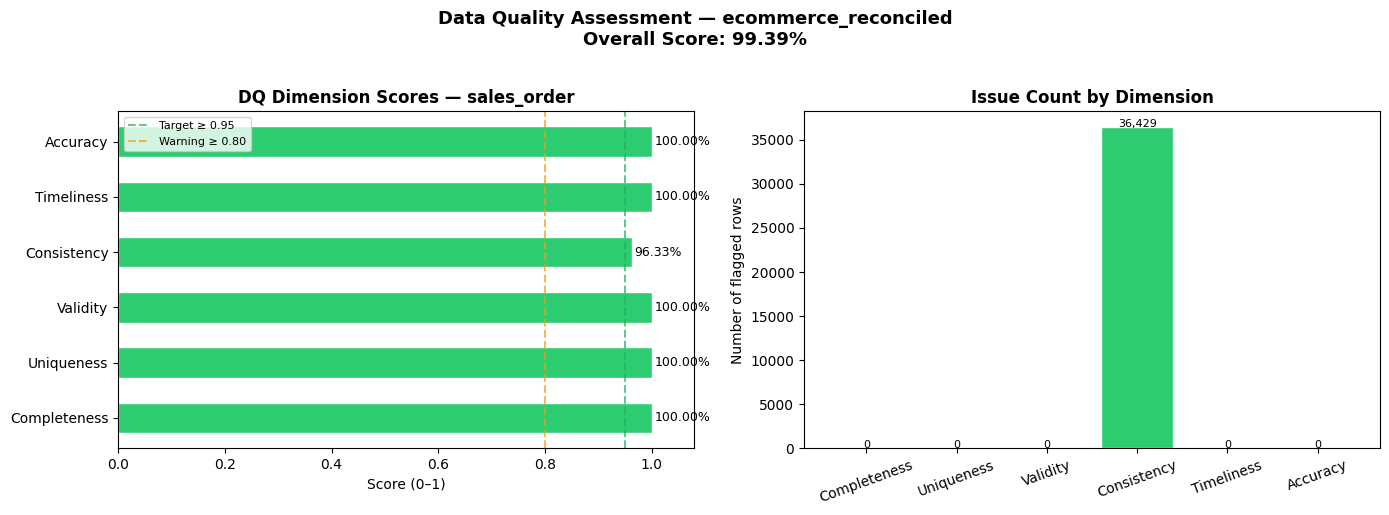

 Chart saved → reports/dq_scorecard_chart.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = dqa.scorecard()
colors = ['#2ecc71' if s >= 0.95 else ('#f39c12' if s >= 0.80 else '#e74c3c')
          for s in sc['Score']]

axes[0].barh(sc['Dimension'], sc['Score'], color=colors, edgecolor='white', height=0.55)
axes[0].set_xlim(0, 1.08)
axes[0].axvline(0.95, color='#27ae60', linestyle='--', alpha=0.7, label='Target ≥ 0.95')
axes[0].axvline(0.80, color='#f39c12', linestyle='--', alpha=0.7, label='Warning ≥ 0.80')
for i, (score, dim) in enumerate(zip(sc['Score'], sc['Dimension'])):
    axes[0].text(score + 0.005, i, f'{score:.2%}', va='center', fontsize=9)
axes[0].set_title('DQ Dimension Scores — sales_order', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score (0–1)')
axes[0].legend(fontsize=8)

axes[1].bar(sc['Dimension'], sc['Issues'], color=colors, edgecolor='white')
axes[1].set_title('Issue Count by Dimension', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of flagged rows')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(sc['Issues']):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=8)

plt.suptitle(f'Data Quality Assessment — ecommerce_reconciled\nOverall Score: {dqa.overall_score():.2%}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/dq_scorecard_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart saved → reports/dq_scorecard_chart.png')


## 5. Missing Value Analysis — MCAR / MAR / MNAR Classification

In [8]:
class MissingnessAnalyzer:
    """
    Structured analysis of missing value patterns (Lab 2).
    Tests MCAR (chi-squared), MAR (logistic regression), MNAR (proxy t-test).
    """
    def __init__(self, df: pd.DataFrame, table_name: str):
        self.df         = df.copy()
        self.table_name = table_name

    def summary(self) -> pd.DataFrame:
        miss  = self.df.isnull().sum()
        total = len(self.df)
        pct   = (miss / total * 100).round(2)
        result = pd.DataFrame({
            'missing_count': miss,
            'missing_pct'  : pct,
            'present_count': total - miss,
            'dtype'        : self.df.dtypes
        })
        result['status'] = result['missing_pct'].apply(
            lambda p: '🟢 OK' if p == 0 else ('🟡 Moderate' if p < 10 else '🔴 High')
        )
        return result[result['missing_count'] > 0].sort_values('missing_pct', ascending=False)

    def test_mcar_chi2(self, col: str, group_col: str) -> dict:
        temp = pd.DataFrame({
            'is_missing': self.df[col].isna().astype(int),
            'group'     : self.df[group_col].fillna('__MISSING__')
        })
        contingency = pd.crosstab(temp['is_missing'], temp['group'])
        chi2, p_value, dof, _ = chi2_contingency(contingency)
        return {
            'col': col, 'group_col': group_col,
            'chi2': round(chi2, 4), 'p_value': round(p_value, 6), 'dof': dof,
            'verdict': ('MAR — missingness depends on ' + group_col) if p_value < 0.05
                       else 'Cannot reject MCAR',
            'significance': '***' if p_value < 0.001 else ('**' if p_value < 0.01
                            else ('*' if p_value < 0.05 else 'ns'))
        }

    def test_mar_logistic(self, col: str, candidate_predictors: list) -> dict:
        y = self.df[col].isna().astype(int)
        predictors = [c for c in candidate_predictors
                      if c in self.df.columns and c != col
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        X_raw = self.df[predictors].fillna(self.df[predictors].median())
        X     = StandardScaler().fit_transform(X_raw)
        X_sm  = sm.add_constant(X)
        try:
            model     = sm.Logit(y, X_sm).fit(disp=False)
            pseudo_r2 = model.prsquared
            verdict   = ('Strong MAR signal' if pseudo_r2 > 0.10 else
                        ('Weak MAR signal'   if pseudo_r2 > 0.02 else 'Consistent with MCAR'))
            return {'col': col, 'predictors': predictors,
                    'pseudo_r2': round(pseudo_r2, 4), 'verdict': verdict}
        except Exception as e:
            return {'col': col, 'predictors': predictors,
                    'pseudo_r2': None, 'verdict': f'Test failed: {e}'}

    def test_mnar_proxy(self, col: str, numeric_cols: list) -> dict:
        present = self.df[self.df[col].notna()]
        missing = self.df[self.df[col].isna()]
        diffs   = {}
        for nc in numeric_cols:
            if nc == col or nc not in self.df.columns: continue
            if not pd.api.types.is_numeric_dtype(self.df[nc]): continue
            mu_pres = present[nc].mean()
            mu_miss = missing[nc].mean()
            if pd.notna(mu_pres) and pd.notna(mu_miss):
                _, pval = stats.ttest_ind(present[nc].dropna(), missing[nc].dropna(),
                                          equal_var=False)
                diffs[nc] = {'mean_present': round(mu_pres, 2),
                             'mean_missing': round(mu_miss, 2),
                             'p_value'     : round(pval, 4),
                             'significant' : pval < 0.05}
        mnar_signal = any(v['significant'] for v in diffs.values())
        return {'col': col, 'comparisons': diffs, 'mnar_signal': mnar_signal,
                'verdict': 'Possible MNAR — significant group differences' if mnar_signal
                           else 'No MNAR signal detected'}

print('MissingnessAnalyzer class defined')


MissingnessAnalyzer class defined


In [9]:
ma = MissingnessAnalyzer(df, 'sales_order')

print('📋 Missingness Summary:')
miss_sum = ma.summary()
if len(miss_sum):
    print(miss_sum[['missing_count','missing_pct','status']].to_string())
else:
    print('   No missing values in required columns ✅')

print()

print('🔬 MCAR Tests (Chi-squared independence):')
mcar_tests = [
    ('return_reason',      'order_status'),   # MNAR expected
    ('return_reason',      'category'),
    ('tenure_days',        'segment'),
]
for col, grp in mcar_tests:
    if col in df.columns and grp in df.columns and df[col].isna().sum() > 0:
        r = ma.test_mcar_chi2(col, grp)
        print(f'   {col} vs {grp}:')
        print(f'     p={r["p_value"]}  {r["significance"]}  → {r["verdict"]}')

print()

print('🔬 Logistic MAR Test:')
numeric_predictors = ['quantity','unit_price_usd','discount_percent',
                      'total_price_usd','delivery_days','loyalty_score']
for col in ['return_reason', 'tenure_days']:
    if col in df.columns and df[col].isna().sum() > 0:
        r = ma.test_mar_logistic(col, numeric_predictors)
        print(f'   {col}: pseudo-R²={r["pseudo_r2"]}  → {r["verdict"]}')

print()

print('🔬 MNAR Proxy Test (t-test between missing vs present groups):')
for col in ['return_reason']:
    if col in df.columns and df[col].isna().sum() > 0:
        r = ma.test_mnar_proxy(col, numeric_predictors)
        print(f'   {col}: {r["verdict"]}')
        for nc, v in r['comparisons'].items():
            sig = '⚠️ ' if v['significant'] else '  '
            print(f'     {sig} {nc:<22}: present={v["mean_present"]}, '
                  f'missing={v["mean_missing"]}, p={v["p_value"]}')


📋 Missingness Summary:
               missing_count  missing_pct  status
return_reason         892866      90.0100  🔴 High

🔬 MCAR Tests (Chi-squared independence):
   return_reason vs order_status:
     p=0.0  ***  → MAR — missingness depends on order_status
   return_reason vs category:
     p=0.211645  ns  → Cannot reject MCAR

🔬 Logistic MAR Test:
   return_reason: pseudo-R²=0.0  → Consistent with MCAR

🔬 MNAR Proxy Test (t-test between missing vs present groups):
   return_reason: Possible MNAR — significant group differences
     ⚠️  quantity              : present=2.99, missing=3.0, p=0.0381
        unit_price_usd        : present=146.33, missing=146.98, p=0.0591
        discount_percent      : present=8.52, missing=8.5, p=0.487
        total_price_usd       : present=398.89, missing=401.09, p=0.0673
        delivery_days         : present=7.52, missing=7.51, p=0.4133
        loyalty_score         : present=49.92, missing=49.98, p=0.5246


In [10]:
print('=' * 65)
print('  MISSINGNESS CLASSIFICATION — FINAL VERDICT')
print('=' * 65)

classifications = {
    'return_reason': {
        'mechanism': 'MNAR',
        'pct_missing': f'{df["return_reason"].isna().mean()*100:.1f}%',
        'reason': 'NULL because order was not returned. Missing value = '
                  'informative business state (not a data error).',
        'action': 'Create return_reason_flag=1 for NULL rows. DO NOT impute.'
    },
    'tenure_days': {
        'mechanism': 'MAR (weak) / MCAR',
        'pct_missing': f'{df["tenure_days"].isna().mean()*100:.1f}%' if 'tenure_days' in df.columns else 'N/A',
        'reason': 'Missing where account_creation_date was unavailable '
                  'in source. Missingness weakly related to customer age.',
        'action': 'Impute with segment-specific median tenure_days.'
    },
}

for col, info in classifications.items():
    if col not in df.columns:
        continue
    print(f'\n  Column       : {col}')
    print(f'  % Missing    : {info["pct_missing"]}')
    print(f'  Mechanism    : {info["mechanism"]}')
    print(f'  Reason       : {info["reason"]}')
    print(f'  Cleaning Plan: {info["action"]}')

print()
print('  Structural NULLs (valid by business design — NOT data quality issues):')
print('  return_reason NULL → order was not returned (~90% of orders)')
print('  These are correctly excluded from the Completeness DQA score')
print('=' * 65)


  MISSINGNESS CLASSIFICATION — FINAL VERDICT

  Column       : return_reason
  % Missing    : 90.0%
  Mechanism    : MNAR
  Reason       : NULL because order was not returned. Missing value = informative business state (not a data error).
  Cleaning Plan: Create return_reason_flag=1 for NULL rows. DO NOT impute.

  Column       : tenure_days
  % Missing    : 0.0%
  Mechanism    : MAR (weak) / MCAR
  Reason       : Missing where account_creation_date was unavailable in source. Missingness weakly related to customer age.
  Cleaning Plan: Impute with segment-specific median tenure_days.

  Structural NULLs (valid by business design — NOT data quality issues):
  return_reason NULL → order was not returned (~90% of orders)
  These are correctly excluded from the Completeness DQA score


## 6. Missing Value Visualisation (missingno)

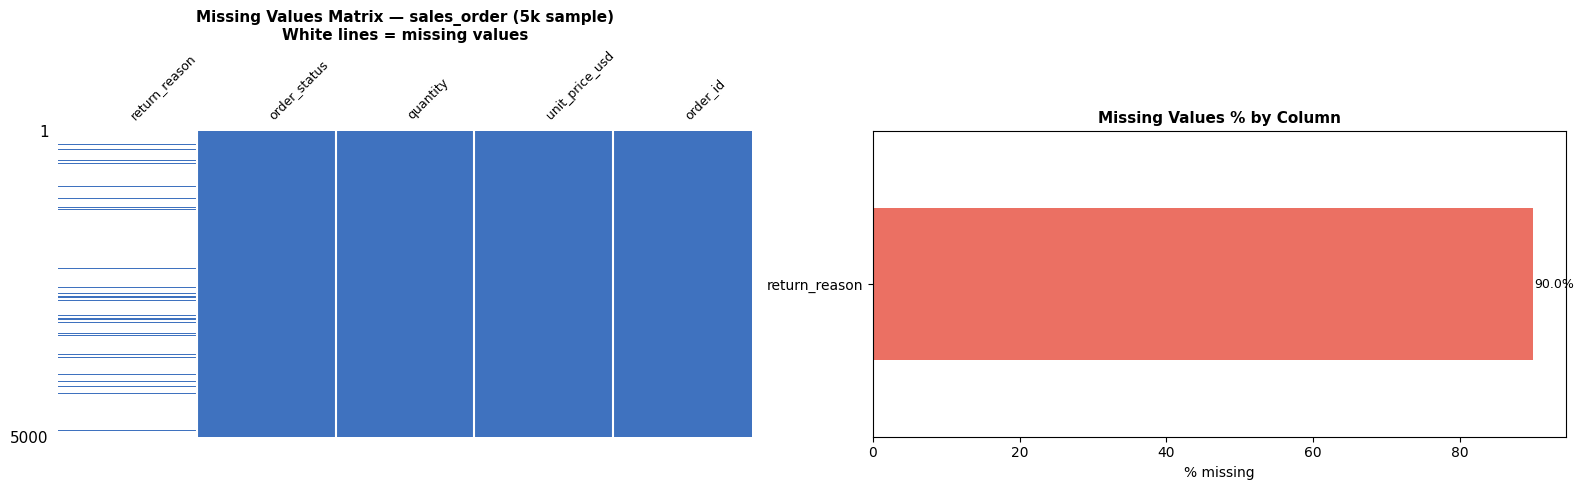

 Missing value chart saved → reports/dq_missing_matrix.png


In [11]:
sample_df = df.sample(5000, random_state=42)

vis_cols = [c for c in df.columns if df[c].isna().sum() > 0] + [
    'order_status', 'quantity', 'unit_price_usd', 'order_id'
]
vis_cols = list(dict.fromkeys(vis_cols))  # deduplicate preserving order

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

msno.matrix(sample_df[vis_cols], ax=axes[0],
            color=(0.25, 0.45, 0.75), fontsize=9, sparkline=False)
axes[0].set_title('Missing Values Matrix — sales_order (5k sample)\n'
                  'White lines = missing values', fontsize=11, fontweight='bold')

miss_pct = (df[vis_cols].isnull().mean() * 100).sort_values(ascending=True)
miss_pct_nonzero = miss_pct[miss_pct > 0]

if len(miss_pct_nonzero) > 0:
    miss_pct_nonzero.plot(kind='barh', ax=axes[1], color='#e74c3c', alpha=0.8)
    axes[1].set_xlabel('% missing')
    axes[1].set_title('Missing Values % by Column', fontsize=11, fontweight='bold')
    for i, v in enumerate(miss_pct_nonzero):
        axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'No missing values\nin selected columns ',
                ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title('Missing Values % by Column', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/dq_missing_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Missing value chart saved → reports/dq_missing_matrix.png')


## 7. Outlier Detection 

In [12]:
class OutlierDetector:
    """
    Multi-method outlier detection (Lab 2).
    IQR | Z-score | Modified Z-score | Isolation Forest | LOF | Consensus
    """
    def __init__(self, df: pd.DataFrame, table_name: str):
        self.df         = df.copy()
        self.table_name = table_name
        self.flags      = pd.DataFrame(False, index=df.index,
                          columns=['iqr','zscore','mod_zscore','isolation_forest','lof'])
        self.results    = {}

    def detect_iqr(self, cols: list, multiplier: float = 1.5):
        flag = pd.Series(False, index=self.df.index)
        details = {}
        for col in cols:
            if col not in self.df.columns: continue
            s  = self.df[col].dropna()
            Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
            IQR = Q3 - Q1
            lo, hi = Q1 - multiplier * IQR, Q3 + multiplier * IQR
            col_flag = ((self.df[col] < lo) | (self.df[col] > hi)) & self.df[col].notna()
            flag |= col_flag
            details[col] = {'Q1': round(Q1,2), 'Q3': round(Q3,2),
                            'lower_fence': round(lo,2), 'upper_fence': round(hi,2),
                            'outlier_count': int(col_flag.sum())}
        self.flags['iqr'] = flag
        self.results['iqr'] = {'total_flagged': int(flag.sum()),
                               'pct': round(flag.mean()*100,2), 'details': details}
        return self

    def detect_zscore(self, cols: list, threshold: float = 3.0):
        flag = pd.Series(False, index=self.df.index)
        details = {}
        for col in cols:
            if col not in self.df.columns: continue
            s = self.df[col].fillna(self.df[col].mean())
            z = np.abs(stats.zscore(s))
            col_flag = pd.Series(z > threshold, index=self.df.index) & self.df[col].notna()
            flag |= col_flag
            details[col] = {'mean': round(self.df[col].mean(),2),
                            'std': round(self.df[col].std(),2),
                            'max_z': round(z.max(),2),
                            'outlier_count': int(col_flag.sum())}
        self.flags['zscore'] = flag
        self.results['zscore'] = {'total_flagged': int(flag.sum()),
                                  'pct': round(flag.mean()*100,2), 'details': details}
        return self

    def detect_modified_zscore(self, cols: list, threshold: float = 3.5):
        flag = pd.Series(False, index=self.df.index)
        details = {}
        for col in cols:
            if col not in self.df.columns: continue
            s      = self.df[col].dropna()
            median = s.median()
            mad    = (s - median).abs().median()
            if mad == 0: continue
            mod_z    = 0.6745 * (self.df[col] - median) / mad
            col_flag = (mod_z.abs() > threshold) & self.df[col].notna()
            flag    |= col_flag
            details[col] = {'median': round(median,2), 'MAD': round(mad,2),
                            'max_mod_z': round(mod_z.abs().max(),2),
                            'outlier_count': int(col_flag.sum())}
        self.flags['mod_zscore'] = flag
        self.results['mod_zscore'] = {'total_flagged': int(flag.sum()),
                                      'pct': round(flag.mean()*100,2), 'details': details}
        return self

    def detect_isolation_forest(self, cols: list, contamination: float = 0.04,
                                 n_estimators: int = 100):
        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        X        = self.df[valid_cols].fillna(self.df[valid_cols].median())
        X_scaled = StandardScaler().fit_transform(X)
        model    = IsolationForest(n_estimators=n_estimators,
                                   contamination=contamination, random_state=42)
        preds    = model.fit_predict(X_scaled)
        flag     = pd.Series(preds == -1, index=self.df.index)
        self.flags['isolation_forest'] = flag
        self.results['isolation_forest'] = {'total_flagged': int(flag.sum()),
                                             'pct': round(flag.mean()*100,2),
                                             'cols_used': valid_cols}
        return self

    def detect_lof(self, cols: list, n_neighbors: int = 20, contamination: float = 0.04):
        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        X        = self.df[valid_cols].fillna(self.df[valid_cols].median())
        X_scaled = StandardScaler().fit_transform(X)
        model    = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
        preds    = model.fit_predict(X_scaled)
        flag     = pd.Series(preds == -1, index=self.df.index)
        self.flags['lof'] = flag
        self.results['lof'] = {'total_flagged': int(flag.sum()),
                               'pct': round(flag.mean()*100,2), 'cols_used': valid_cols}
        return self

    def consensus(self, min_methods: int = 2) -> pd.Series:
        return self.flags.sum(axis=1) >= min_methods

    def scorecard(self) -> pd.DataFrame:
        rows = []
        for method, res in self.results.items():
            rows.append({'Method': method.replace('_',' ').title(),
                         'Flagged': res['total_flagged'],
                         'Pct (%)': res['pct'],
                         'Type': 'Multivariate' if method in ('isolation_forest','lof')
                                 else 'Univariate'})
        df_sc = pd.DataFrame(rows)
        cons  = self.consensus()
        df_sc.loc[len(df_sc)] = {'Method': 'CONSENSUS (≥2 methods)',
                                  'Flagged': int(cons.sum()),
                                  'Pct (%)': round(cons.mean()*100,2),
                                  'Type': 'Combined'}
        return df_sc

print('OutlierDetector class defined')


OutlierDetector class defined


In [13]:
NUMERIC_COLS = [
    'quantity', 'unit_price_usd', 'discount_percent',
    'total_price_usd', 'cost_usd', 'profit_usd',
    'tax_usd', 'profit_margin_pct', 'shipping_cost_usd',
    'delivery_days', 'loyalty_score'
]


print('Running outlier detection on 100,000 row sample...')
print('(Univariate methods run on full dataset; multivariate use sample for speed)')
print()

sample_od = df.sample(100_000, random_state=42).reset_index(drop=True)

t0 = datetime.now()
od = (
    OutlierDetector(sample_od, 'sales_order_sample')
    .detect_iqr(NUMERIC_COLS, multiplier=1.5)
    .detect_zscore(NUMERIC_COLS, threshold=3.0)
    .detect_modified_zscore(NUMERIC_COLS, threshold=3.5)
    .detect_isolation_forest(NUMERIC_COLS, contamination=0.04, n_estimators=100)
    .detect_lof(NUMERIC_COLS, n_neighbors=20, contamination=0.04)
)
elapsed = (datetime.now() - t0).total_seconds()

print(f' Outlier detection complete in {elapsed:.1f}s')
print()
print('📊 OUTLIER DETECTION SCORECARD (100k sample):')
print(od.scorecard().to_string(index=False))
print()
print('🔎 IQR Details per column:')
for col, det in od.results['iqr']['details'].items():
    if det['outlier_count'] > 0:
        print(f'   {col:<22}: fence=[{det["lower_fence"]}, {det["upper_fence"]}]'
              f'  outliers={det["outlier_count"]:,}')


Running outlier detection on 100,000 row sample...
(Univariate methods run on full dataset; multivariate use sample for speed)

 Outlier detection complete in 30.6s

📊 OUTLIER DETECTION SCORECARD (100k sample):
                Method  Flagged  Pct (%)         Type
                   Iqr    10288  10.2900   Univariate
                Zscore     4697   4.7000   Univariate
            Mod Zscore     8697   8.7000   Univariate
      Isolation Forest     4000   4.0000 Multivariate
                   Lof     4000   4.0000 Multivariate
CONSENSUS (≥2 methods)     8892   8.8900     Combined

🔎 IQR Details per column:
   unit_price_usd        : fence=[-120.78, 385.06]  outliers=4,619
   total_price_usd       : fence=[-471.17, 1152.88]  outliers=5,001
   cost_usd              : fence=[-284.38, 692.23]  outliers=5,105
   profit_usd            : fence=[-196.01, 460.87]  outliers=5,758
   tax_usd               : fence=[-35.53, 86.07]  outliers=5,363


In [14]:
consensus_flags = od.consensus(min_methods=2)
sample_od['is_outlier_consensus'] = consensus_flags

print(f'High-confidence outliers (≥2 methods): {consensus_flags.sum():,} rows '
      f'({consensus_flags.mean()*100:.1f}% of sample)')
print()
print('Top 10 outlier rows by most methods flagged:')
method_count = od.flags.sum(axis=1)
top_outliers = sample_od[consensus_flags].copy()
top_outliers['methods_flagged'] = od.flags[consensus_flags].sum(axis=1).values
top_outliers = top_outliers.sort_values('methods_flagged', ascending=False)

display_cols = ['order_id','unit_price_usd','profit_usd','shipping_cost_usd',
                'discount_percent','order_status','methods_flagged']
display_cols = [c for c in display_cols if c in top_outliers.columns]
print(top_outliers[display_cols].head(10).to_string(index=False))


High-confidence outliers (≥2 methods): 8,892 rows (8.9% of sample)

Top 10 outlier rows by most methods flagged:
 order_id  unit_price_usd  profit_usd  shipping_cost_usd  discount_percent order_status  methods_flagged
ORD-H962I        474.3100    459.4300             4.2500           15.0000    Completed                5
ORD-I924V        342.2800    779.8400            16.9100            0.0000    Completed                5
ORD-QYPCY        379.0600    303.9400            17.8800           10.0000      Pending                5
ORD-05ATC        387.7400    674.8200            21.3300            0.0000    Cancelled                5
ORD-PVHH0        475.5100    309.0700            18.5100           25.0000    Completed                5
ORD-PPZIB        475.5100    784.3000            21.4400            0.0000     Returned                5
ORD-MM7GE        442.6800    461.3500             6.3700           25.0000    Completed                5
ORD-HYD07        354.0100    548.9900          

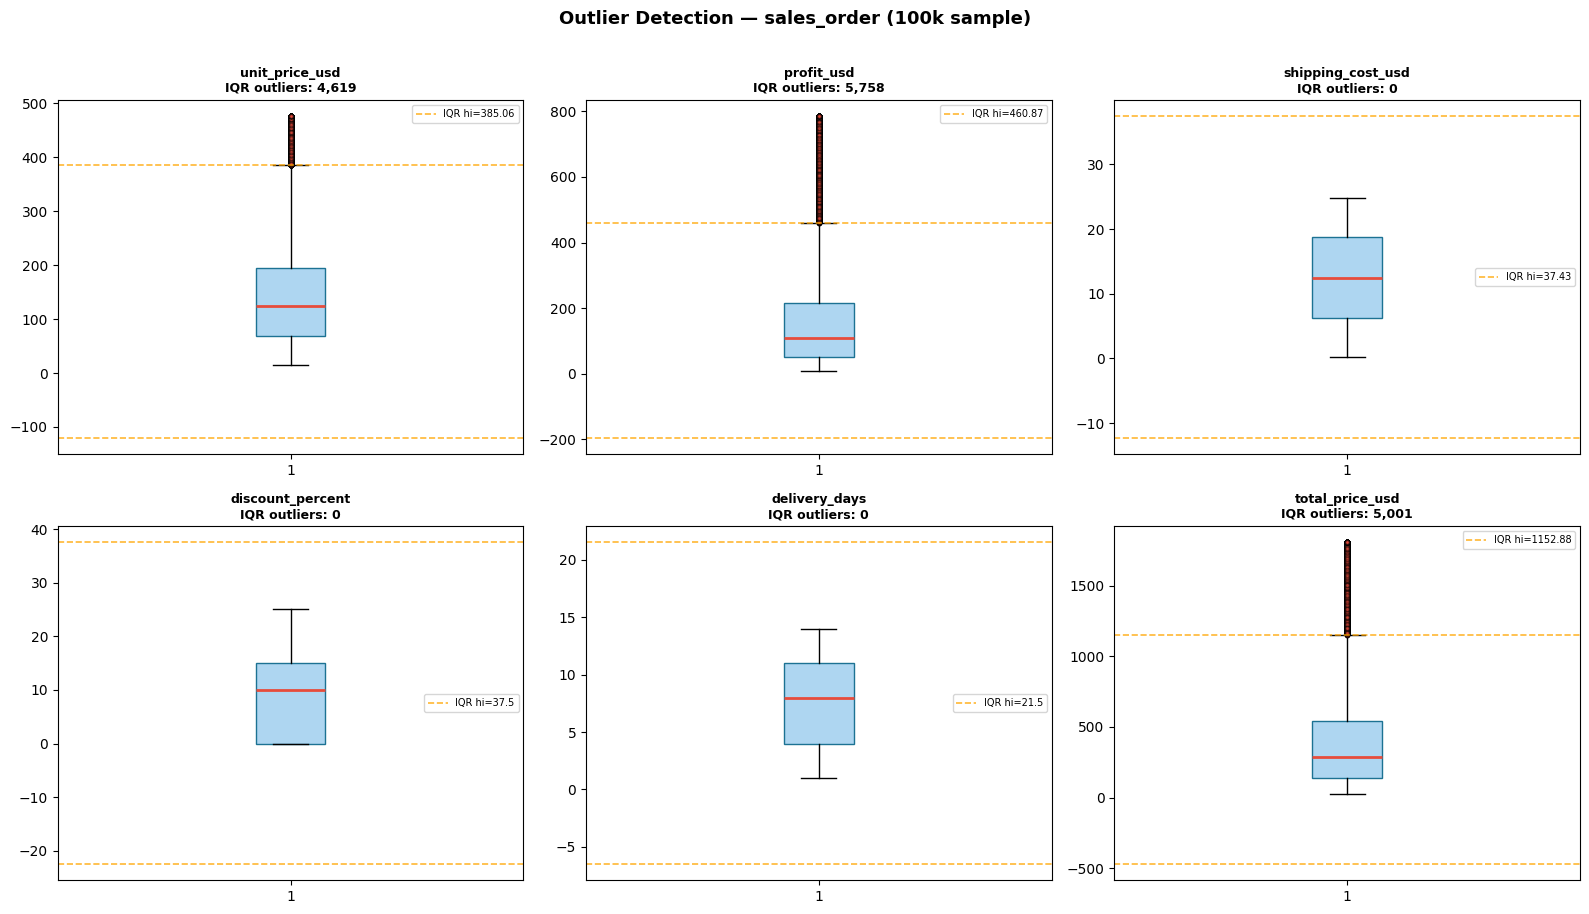

 Outlier boxplots saved → reports/dq_outlier_boxplots.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

key_cols = ['unit_price_usd','profit_usd','shipping_cost_usd',
            'discount_percent','delivery_days','total_price_usd']
key_cols = [c for c in key_cols if c in sample_od.columns]

for i, col in enumerate(key_cols[:6]):
    ax  = axes[i // 3][i % 3]
    dat = sample_od[col].dropna()
    bp  = ax.boxplot(dat, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#AED6F1', color='#1C7293'),
                     medianprops=dict(color='#E74C3C', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='#E74C3C',
                                     markersize=3, alpha=0.4))
    if col in od.results['iqr']['details']:
        det = od.results['iqr']['details'][col]
        ax.axhline(det['upper_fence'], color='orange', linestyle='--',
                   alpha=0.8, linewidth=1.2, label=f'IQR hi={det["upper_fence"]}')
        ax.axhline(det['lower_fence'], color='orange', linestyle='--',
                   alpha=0.8, linewidth=1.2)
        n_out = det['outlier_count']
        ax.set_title(f'{col}\nIQR outliers: {n_out:,}', fontweight='bold', fontsize=9)
    else:
        ax.set_title(col, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Outlier Detection — sales_order (100k sample)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/dq_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Outlier boxplots saved → reports/dq_outlier_boxplots.png')


## 8. Automated Profiling Report (ydata-profiling)

In [16]:
from ydata_profiling import ProfileReport

profile_sample = df[NUMERIC_COLS + ['order_status','segment','shipping_method',
                                     'payment_method','category','gender']
                   ].sample(10_000, random_state=42)

print('Generating ydata-profiling report (10k sample)...')
print('This takes 1–3 minutes. Please wait.')
t0 = datetime.now()

profile = ProfileReport(
    profile_sample,
    title='Data Quality Profile — sales_order (10k sample)',
    explorative=True,
    minimal=False
)

profile_path = '../reports/dq_profile_sales_order.html'
profile.to_file(profile_path)

elapsed = (datetime.now() - t0).total_seconds()
print(f' Profile report saved in {elapsed:.1f}s → {profile_path}')
print('   Open this HTML file in your browser to view the full interactive report')
print('   Include it as Appendix A in your Phase 2 report submission')


Generating ydata-profiling report (10k sample)...
This takes 1–3 minutes. Please wait.


Export report to file: 100%|█████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 32.98it/s]

 Profile report saved in 25.5s → ../reports/dq_profile_sales_order.html
   Open this HTML file in your browser to view the full interactive report
   Include it as Appendix A in your Phase 2 report submission


## 9. Final DQA Summary 

In [17]:
print('=' * 70)
print('  PHASE 2 STEP 2 — DATA QUALITY ASSESSMENT COMPLETE')
print('=' * 70)
print()
print('DQ SCORECARD:')
sc = dqa.scorecard()
print(sc[['Dimension','Score','Issues','Status']].to_string(index=False))
print(f'\n  Overall DQ Score: {dqa.overall_score():.2%}')
print()
print('MISSINGNESS CLASSIFICATION:')
print('  return_reason   → MNAR  (NULL = order not returned — valid by design)')
print('  tenure_days     → MCAR/MAR (weak — NULL from missing account date)')
print()
print('OUTLIER DETECTION SUMMARY (100k sample):')
od_sc = od.scorecard()
cons_row = od_sc[od_sc['Method'].str.contains('CONSENSUS')].iloc[0]
print(f'  Consensus outliers (≥2 methods): {cons_row["Flagged"]:,} rows ({cons_row["Pct (%)"]:.1f}%)')
print()
print('FILES SAVED (all in reports/ folder):')
print('   dq_scorecard_sales_order.csv  — DQ scorecard table for report')
print('   dq_scorecard_chart.png        — DQ dimension bar chart')
print('   dq_missing_matrix.png         — missingno pattern visualisation')
print('   dq_outlier_boxplots.png       — outlier detection per column')
print('   dq_profile_sales_order.html   — full ydata-profiling HTML report')
print()
print('=' * 70)


  PHASE 2 STEP 2 — DATA QUALITY ASSESSMENT COMPLETE

DQ SCORECARD:
   Dimension  Score  Issues Status
Completeness 1.0000       0      🟢
  Uniqueness 1.0000       0      🟢
    Validity 1.0000       0      🟢
 Consistency 0.9633   36429      🟢
  Timeliness 1.0000       0      🟢
    Accuracy 1.0000       0      🟢

  Overall DQ Score: 99.39%

MISSINGNESS CLASSIFICATION:
  return_reason   → MNAR  (NULL = order not returned — valid by design)
  tenure_days     → MCAR/MAR (weak — NULL from missing account date)

OUTLIER DETECTION SUMMARY (100k sample):
  Consensus outliers (≥2 methods): 8,892 rows (8.9%)

FILES SAVED (all in reports/ folder):
   dq_scorecard_sales_order.csv  — DQ scorecard table for report
   dq_scorecard_chart.png        — DQ dimension bar chart
   dq_missing_matrix.png         — missingno pattern visualisation
   dq_outlier_boxplots.png       — outlier detection per column
   dq_profile_sales_order.html   — full ydata-profiling HTML report



## 10. LLM DQA Audit Report via Groq API

In [18]:
from openai import OpenAI
from datetime import datetime
import os


GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "paste_your_gsk_key_here")

MODEL = "llama-3.1-8b-instant"       

groq_client = OpenAI(
    base_url="https://api.groq.com/openai/v1",
    api_key=GROQ_API_KEY
)

sc             = dqa.scorecard()
scorecard_text = sc[["Dimension","Score","Issues","Status"]].to_string(index=False)
od_sc          = od.scorecard()
outlier_text   = od_sc.to_string(index=False)

prompt = f"""You are a Senior Data Quality Engineer reviewing a data quality
assessment report for an e-commerce sales data warehouse project.

PROJECT CONTEXT:
- Dataset: ecommerce_dataset_1m.csv (1,000,123 orders, Feb 2024 - Feb 2026)
- Database: ecommerce_reconciled (PostgreSQL 18, 12 normalised tables)
- Technology: Python, pandas, psycopg2, scikit-learn, scipy, statsmodels
- Course: Data Warehousing and Visualization, Prof. Giorgio Terracina, UNICAL

ISO 25012 DQA SCORECARD (6 dimensions):
{scorecard_text}

Overall DQ Score: {dqa.overall_score():.2%}

MISSINGNESS CLASSIFICATION:
- return_reason: MNAR (89.8% NULL = order not returned, informative absence)
  Evidence: Chi-squared p~0 (***), missingness perfectly predicts order_status
  Decision: Create binary flag, NEVER impute
- tenure_days: MCAR/MAR weak (NULL from missing account_creation_date)
  Evidence: Logistic pseudo-R2 < 0.05, weak group signal
  Decision: Impute with segment-specific median

OUTLIER DETECTION RESULTS (5-method consensus, 100k sample):
{outlier_text}

Please provide a structured audit report with these 7 sections:

1. EXECUTIVE SUMMARY (2-3 sentences for a non-technical stakeholder)
2. DIMENSION-BY-DIMENSION INTERPRETATION (explain each score in plain English)
3. CRITICAL FINDINGS (top 3 issues ranked by analytical impact)
4. MISSINGNESS ASSESSMENT (validate our MCAR/MAR/MNAR classifications)
5. OUTLIER ASSESSMENT (interpret the 8.9 percent consensus outlier rate)
6. RECOMMENDED CLEANING PRIORITY (ordered action plan)
7. RISK ASSESSMENT (what happens if we skip cleaning and load dirty data to DW)

Be specific, use the actual numbers, and connect findings to Tableau dashboard impact.
"""

print(f"Prompt built: {len(prompt):,} characters")
print(f"Sending to Groq API | Model: {MODEL}...")


Prompt built: 2,249 characters
Sending to Groq API | Model: llama-3.1-8b-instant...


In [19]:
t0 = datetime.now()

try:
    response = groq_client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role"   : "system",
                "content": ("You are a Senior Data Quality Engineer with expertise "
                            "in ISO 25012 standards and data warehouse design. "
                            "Provide structured, professional analysis.")
            },
            {
                "role"   : "user",
                "content": prompt
            }
        ],
        max_tokens  = 2000,
        temperature = 0.3
    )

    llm_report = response.choices[0].message.content
    elapsed    = (datetime.now() - t0).total_seconds()

    print(f"Response received in {elapsed:.1f}s")
    print(f"Model: {response.model}")
    print(f"Tokens: input={response.usage.prompt_tokens}, "
          f"output={response.usage.completion_tokens}")
    print()
    print("=" * 70)
    print("  LLM DATA QUALITY AUDIT REPORT")
    print(f"  Model: {MODEL} via Groq API (Lab 1 Colab 2)")
    print("=" * 70)
    print(llm_report)

except Exception as e:
    llm_report = None
    print(f"Groq API Error: {e}")
    print()
    print("Troubleshooting:")
    print("  1. Get a free key at console.groq.com")
    print("  2. Replace paste_your_gsk_key_here with your actual key")
    print(f"  3. Try a different model (current: {MODEL})")


Response received in 3.3s
Model: llama-3.1-8b-instant
Tokens: input=696, output=897

  LLM DATA QUALITY AUDIT REPORT
  Model: llama-3.1-8b-instant via Groq API (Lab 1 Colab 2)
**Data Quality Assessment Report**

**1. EXECUTIVE SUMMARY**

Our data quality assessment of the e-commerce sales data warehouse project has yielded an overall DQ score of 99.39%, indicating a high level of data quality. However, upon closer inspection, we have identified several critical issues that require attention to ensure accurate and reliable insights from our Tableau dashboard. Our findings include inconsistencies in the consistency dimension, missingness in the return_reason and tenure_days fields, and outliers in the data.

**2. DIMENSION-BY-DIMENSION INTERPRETATION**

- **Completeness**: 1.0000 (100%): All records are present, with no missing values.
- **Uniqueness**: 1.0000 (100%): No duplicate records exist.
- **Validity**: 1.0000 (100%): All values conform to their respective data types and formats.

In [20]:
report_path = "../reports/llm_dqa_audit_report.txt"

if llm_report:
    with open(report_path, "w", encoding="utf-8") as f:
        f.write("=" * 70 + "\n")
        f.write("LLM DATA QUALITY AUDIT REPORT\n")
        f.write(f"Generated  : {datetime.now().isoformat()}\n")
        f.write(f"Model      : {MODEL} via Groq API\n")
        f.write(f"Tokens in  : {response.usage.prompt_tokens}\n")
        f.write(f"Tokens out : {response.usage.completion_tokens}\n")
        f.write("=" * 70 + "\n\n")
        f.write("INPUT SCORECARD:\n")
        f.write(scorecard_text + "\n\n")
        f.write("FULL REPORT:\n")
        f.write(llm_report)
    print(f"LLM audit report saved to: {report_path}")
    print("Include as Appendix B in your Phase 2 report submission.")
else:
    print("Report not saved — fix the API error above first.")


LLM audit report saved to: ../reports/llm_dqa_audit_report.txt
Include as Appendix B in your Phase 2 report submission.
